# Strava Fitness Data Analytics — Exploratory Data Analysis
**Case study:** How can a wellness technology company (Bellabeat) play it smart?

**Business task:** Analyse how people use their fitness trackers and turn those patterns into marketing recommendations for Bellabeat.

**Data:** FitBit Fitness Tracker Data (Möbius, Kaggle; CC0), 33 users, 12 Apr – 12 May 2016.
The raw CSVs were loaded and cleaned into SQLite by `scripts/build_database.py` + `sql/01_data_cleaning.sql`.
This notebook reads the **clean** tables from `database/strava_fitness.db` and explores them with pandas, Matplotlib and Seaborn.

| Section | Question |
|---|---|
| 1 | Setup and data load |
| 2 | Data quality recap |
| 3 | Which features do users use? |
| 4 | How active are users (steps, time use)? |
| 5 | When are users active (weekday, hour)? |
| 6 | How well do users sleep? |
| 7 | Heart rate patterns |
| 8 | User segments and engagement |
| 9 | Correlations |
| 10 | Key findings |

## 1. Setup and data load

In [1]:
import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Paths work whether the notebook runs from the project root or from /notebooks
ROOT = Path.cwd() if (Path.cwd() / "database").exists() else Path.cwd().parent
DB_PATH = ROOT / "database" / "strava_fitness.db"
IMG_DIR = ROOT / "images"
IMG_DIR.mkdir(exist_ok=True)

# Colour palette (colour-blind-safe, fixed order)
BLUE, ORANGE, AQUA, YELLOW, GREY = "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#9a9892"
WEEKDAYS = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

sns.set_theme(style="whitegrid", font_scale=1.0)
plt.rcParams.update({
    "figure.figsize": (10, 4.8), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titleweight": "bold", "axes.titlesize": 13, "axes.titlelocation": "left",
    "grid.color": "#e6e5e1", "grid.linewidth": 0.8,
})

def save(fig, name):
    fig.savefig(IMG_DIR / f"{name}.png", bbox_inches="tight", dpi=130)

conn = sqlite3.connect(DB_PATH)
sql = lambda q: pd.read_sql(q, conn)

daily   = sql("SELECT * FROM daily_summary")
hourly  = sql("SELECT * FROM hourly_activity")
sleep   = sql("SELECT * FROM sleep_day")
sess    = sql("SELECT * FROM sleep_sessions")
hr_hour = sql("SELECT * FROM heart_rate_hourly")
users   = sql("SELECT * FROM user_profile")
weight  = sql("SELECT * FROM weight_log")

for name, df in {"daily": daily, "hourly": hourly, "sleep": sleep, "sleep_sessions": sess,
                 "heart_rate_hourly": hr_hour, "users": users, "weight": weight}.items():
    print(f"{name:<18} {df.shape[0]:>7,} rows x {df.shape[1]} cols")

daily                  863 rows x 23 cols
hourly              22,099 rows x 10 cols
sleep                  410 rows x 9 cols
sleep_sessions         459 rows x 11 cols
heart_rate_hourly    6,013 rows x 8 cols
users                   33 rows x 18 cols
weight                  67 rows x 6 cols


## 2. Data quality recap
Every cleaning step was done in SQL and logged in the `cleaning_log` table.

In [2]:
sql("SELECT step_no, table_name, action, rows_before, rows_after, rows_removed FROM cleaning_log")

,step_no,table_name,action,rows_before,rows_after,rows_removed
0,1,raw_daily_activity,Check: rows with negative values (none expected),940,940,0.0
1,1,raw_daily_activity,Check: rows with NULL Id / date / steps / calo...,940,940,0.0
2,2,daily_activity,Removed non-wear days (TotalSteps = 0),940,863,77.0
3,3,sleep_day,Removed exact duplicate rows,413,410,3.0
4,4,sleep_sessions,"Removed duplicate minute-sleep rows, then grou...",188521,187978,543.0
5,5,weight_log,Dropped Fat (97% empty) and WeightPounds (dupl...,67,67,0.0
6,6,hourly_activity,Joined hourly steps + calories + intensities o...,22099,22099,0.0
7,7,heart_rate_hourly,Aggregated second-level heart rate to user-hour,2483658,6013,NaN


In [3]:
# Sanity checks on the clean data
print("Nulls in daily activity columns:", daily[["total_steps", "calories", "sedentary_min"]].isna().sum().sum())
print("Duplicate user-days:", daily.duplicated(["user_id", "activity_date"]).sum())
print("Days per user:"); print(daily.groupby("user_id").size().describe().round(1))

Nulls in daily activity columns: 0
Duplicate user-days: 0
Days per user:
count    33.0
mean     26.2
std       6.8
min       3.0
25%      21.0
50%      30.0
75%      31.0
max      31.0
dtype: float64


**Notes**
- 77 days with **0 steps** were removed: the tracker logged ~24 h of sedentary time with no movement, meaning it was not worn.
- The distance unit is not documented, so distance is used only for relative comparisons.
- Only 33 users (24 with sleep, 14 with heart rate, 8 with weight) and no demographics, so results are **directional**, not representative of Bellabeat's female customer base.

## 3. Which features do users use?

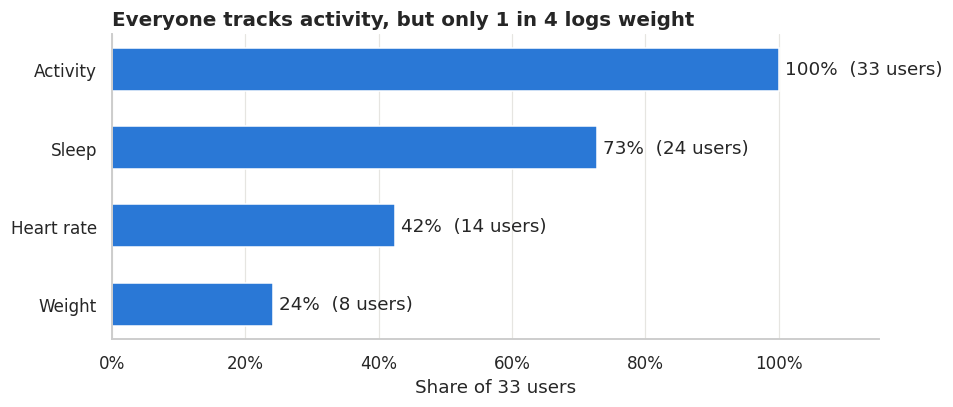

In [4]:
adoption = pd.DataFrame({
    "feature": ["Activity", "Sleep", "Heart rate", "Weight"],
    "users": [daily.user_id.nunique(), sleep.user_id.nunique(),
              hr_hour.user_id.nunique(), weight.user_id.nunique()],
})
adoption["pct"] = adoption.users / 33 * 100

fig, ax = plt.subplots(figsize=(9, 3.6))
bars = ax.barh(adoption.feature[::-1], adoption.pct[::-1], color=BLUE, height=0.55)
ax.bar_label(bars, labels=[f"{p:.0f}%  ({u} users)" for p, u in zip(adoption.pct[::-1], adoption.users[::-1])], padding=4)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlim(0, 115); ax.set_xlabel("Share of 33 users"); ax.grid(axis="y", visible=False)
ax.set_title("Everyone tracks activity, but only 1 in 4 logs weight")
save(fig, "01_feature_adoption"); plt.show()

**Insight:** Automatic features win. Activity is tracked by all users, sleep by 73 %, heart rate by 42 %, and manual weight logging by only 24 %. Friction (manual entry, wearing at night) reduces adoption.

## 4. How active are users?

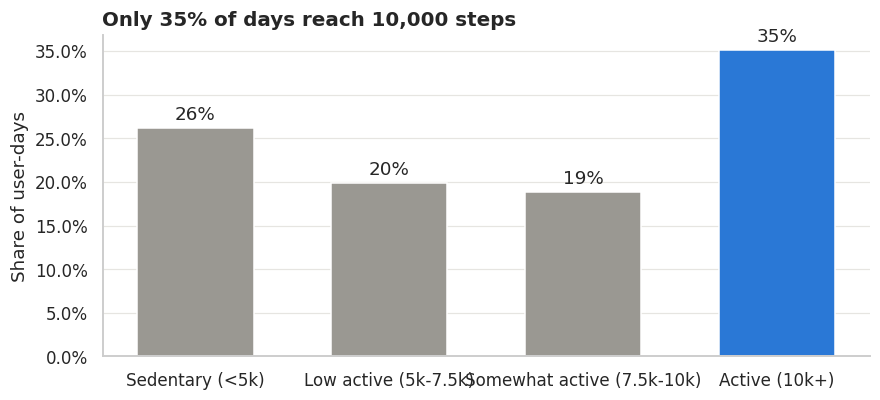

Average daily steps: 8,319  |  median: 8,053


In [5]:
bands = daily.step_band.value_counts().sort_index()
labels = [b.split(". ")[1] for b in bands.index]

fig, ax = plt.subplots(figsize=(9, 3.8))
bars = ax.bar(labels, bands.values / bands.sum() * 100, color=[GREY, GREY, GREY, BLUE], width=0.6)
ax.bar_label(bars, fmt="%.0f%%", padding=3)
ax.yaxis.set_major_formatter(mtick.PercentFormatter()); ax.set_ylabel("Share of user-days")
ax.set_title("Only 35% of days reach 10,000 steps"); ax.grid(axis="x", visible=False)
save(fig, "02_step_bands"); plt.show()

print(f"Average daily steps: {daily.total_steps.mean():,.0f}  |  median: {daily.total_steps.median():,.0f}")

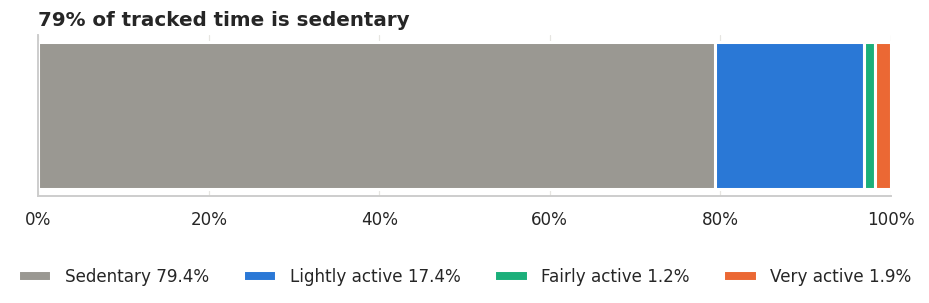

In [6]:
time_use = daily[["sedentary_min", "lightly_active_min", "fairly_active_min", "very_active_min"]].sum()
share = time_use / time_use.sum() * 100
names = ["Sedentary", "Lightly active", "Fairly active", "Very active"]

fig, ax = plt.subplots(figsize=(10, 1.9))
left = 0
for val, name, col in zip(share, names, [GREY, BLUE, AQUA, ORANGE]):
    ax.barh([0], [val], left=left, color=col, edgecolor="white", linewidth=2, label=f"{name} {val:.1f}%")
    left += val
ax.set_xlim(0, 100); ax.set_yticks([]); ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.35), frameon=False)
ax.set_title("79% of tracked time is sedentary")
save(fig, "03_time_use"); plt.show()

**Insight:** Most tracked time is sedentary (79 %). Of the active time, most is *light* activity; fairly and very active minutes together are only ~3 % of the day.

## 5. When are users active?

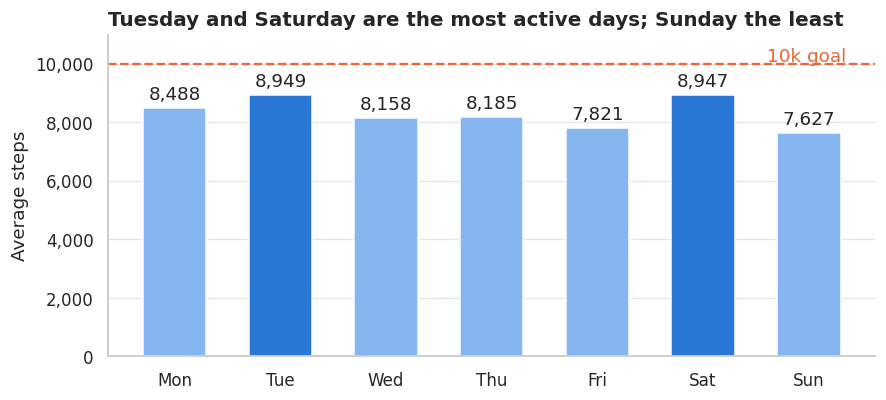

In [7]:
by_day = daily.groupby("weekday").agg(avg_steps=("total_steps", "mean"),
                                       avg_sleep=("hours_asleep", "mean")).reindex(WEEKDAYS)

fig, ax = plt.subplots(figsize=(9, 3.8))
colors = [BLUE if d in ("Tuesday", "Saturday") else "#86b6ef" for d in by_day.index]
bars = ax.bar([d[:3] for d in by_day.index], by_day.avg_steps, color=colors, width=0.6)
ax.bar_label(bars, fmt="{:,.0f}", padding=3)
ax.axhline(10000, color=ORANGE, lw=1.5, ls="--"); ax.text(6.35, 10100, "10k goal", color=ORANGE, ha="right")
ax.set_ylim(0, 11000); ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}")); ax.set_ylabel("Average steps"); ax.grid(axis="x", visible=False)
ax.set_title("Tuesday and Saturday are the most active days; Sunday the least")
save(fig, "04_steps_by_weekday"); plt.show()

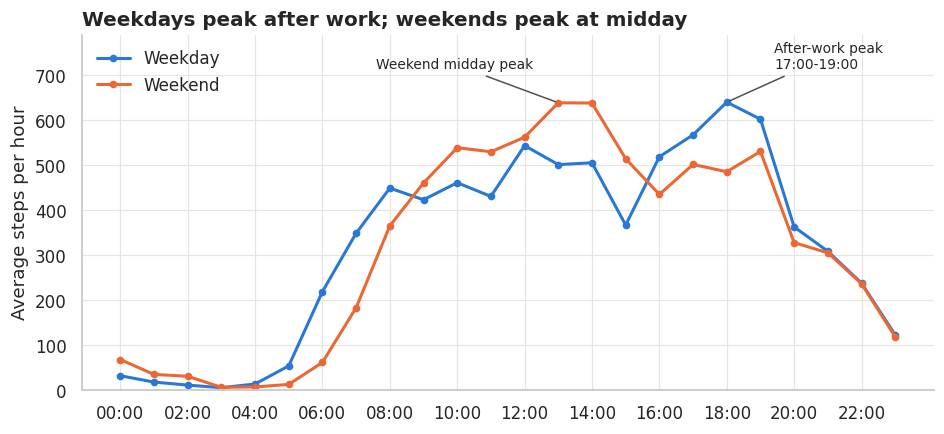

In [8]:
hourly["day_type"] = np.where(hourly.weekday_num.isin([0, 6]), "Weekend", "Weekday")
hp = hourly.groupby(["hour_of_day", "day_type"]).steps.mean().unstack()

fig, ax = plt.subplots(figsize=(10, 4.2))
ax.plot(hp.index, hp.Weekday, color=BLUE, lw=2, marker="o", ms=4, label="Weekday")
ax.plot(hp.index, hp.Weekend, color=ORANGE, lw=2, marker="o", ms=4, label="Weekend")
ax.set_xticks(range(0, 24, 2)); ax.set_xticklabels([f"{h:02d}:00" for h in range(0, 24, 2)], rotation=0)
ax.set_ylabel("Average steps per hour"); ax.set_ylim(0, 790); ax.legend(frameon=False, loc="upper left")
ax.annotate("After-work peak\n17:00-19:00", xy=(18, hp.Weekday[18]), xytext=(19.4, 715),
            arrowprops=dict(arrowstyle="-", color="#52514e"), fontsize=9)
ax.annotate("Weekend midday peak", xy=(13, hp.Weekend[13]), xytext=(7.6, 715),
            arrowprops=dict(arrowstyle="-", color="#52514e"), fontsize=9)
ax.set_title("Weekdays peak after work; weekends peak at midday")
save(fig, "05_hourly_pattern"); plt.show()

**Insight:** On weekdays activity peaks at **17:00–19:00** (after work) with a smaller lunchtime bump. At weekends people start later and are most active between **10:00 and 15:00**. These are the best windows for reminders and challenges.

## 6. How well do users sleep?

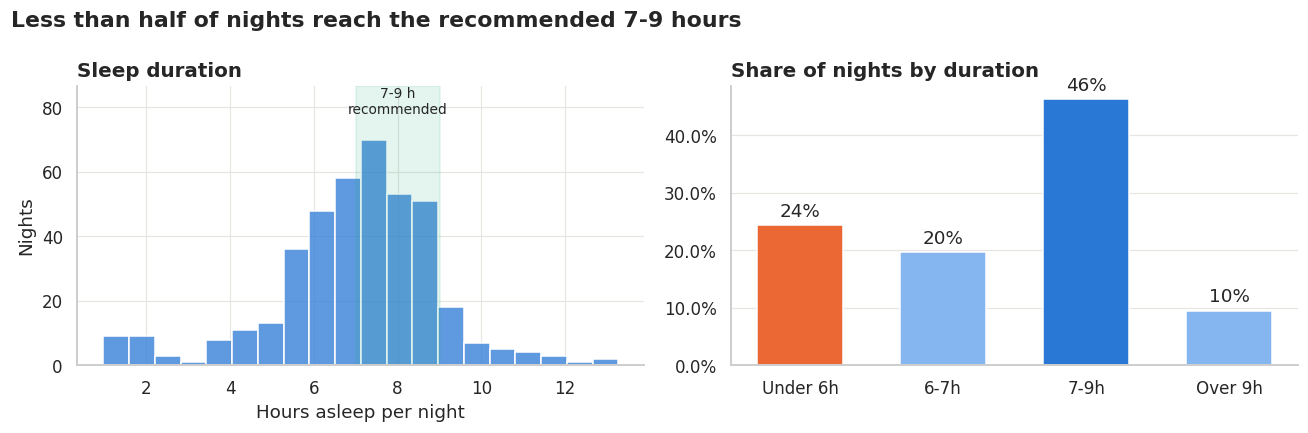

Average sleep: 6.99 h | Average time awake in bed: 39 min


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ax = axes[0]
sns.histplot(sleep.hours_asleep, bins=20, color=BLUE, ax=ax, edgecolor="white")
ax.set_ylim(0, ax.get_ylim()[1] * 1.18); ax.axvspan(7, 9, color=AQUA, alpha=0.12); ax.text(8, ax.get_ylim()[1] * 0.9, "7-9 h\nrecommended", ha="center", fontsize=9)
ax.set_xlabel("Hours asleep per night"); ax.set_ylabel("Nights"); ax.set_title("Sleep duration")

ax = axes[1]
sb = sleep.sleep_band.value_counts(normalize=True).sort_index() * 100
bars = ax.bar([b.split(". ")[1].replace(" (recommended)", "") for b in sb.index], sb.values,
              color=[ORANGE, "#86b6ef", BLUE, "#86b6ef"], width=0.6)
ax.bar_label(bars, fmt="%.0f%%", padding=3); ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title("Share of nights by duration"); ax.grid(axis="x", visible=False)
fig.suptitle("Less than half of nights reach the recommended 7-9 hours", x=0.01, ha="left", fontweight="bold")
fig.tight_layout(); save(fig, "06_sleep_distribution"); plt.show()

print(f"Average sleep: {sleep.hours_asleep.mean():.2f} h | Average time awake in bed: {sleep.minutes_awake_in_bed.mean():.0f} min")

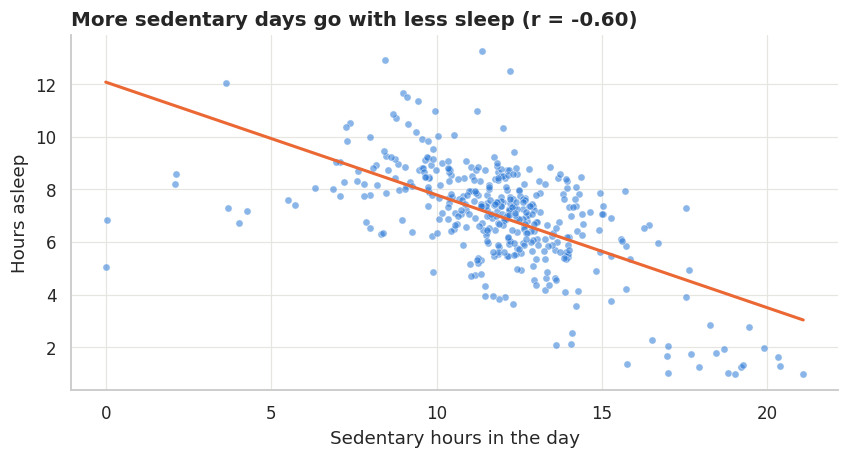

In [10]:
fig, ax = plt.subplots(figsize=(9, 4.2))
d = daily.dropna(subset=["hours_asleep"])
ax.scatter(d.sedentary_min / 60, d.hours_asleep, s=22, color=BLUE, alpha=0.55, edgecolor="white", linewidth=0.5)
m, b = np.polyfit(d.sedentary_min / 60, d.hours_asleep, 1)
xs = np.linspace(d.sedentary_min.min() / 60, d.sedentary_min.max() / 60, 50)
ax.plot(xs, m * xs + b, color=ORANGE, lw=2)
r = d[["sedentary_min", "hours_asleep"]].corr().iloc[0, 1]
ax.set_xlabel("Sedentary hours in the day"); ax.set_ylabel("Hours asleep")
ax.set_title(f"More sedentary days go with less sleep (r = {r:.2f})")
save(fig, "07_sedentary_vs_sleep"); plt.show()

**Insight:** Only **46 %** of nights hit 7–9 hours, and a quarter are under 6 hours. Days with more sedentary time are strongly linked to shorter sleep (r ≈ −0.6).

*Caveat:* when the tracker is worn at night, awake-in-bed time can count as sedentary, which strengthens this link. It is a correlation, not proof of cause.

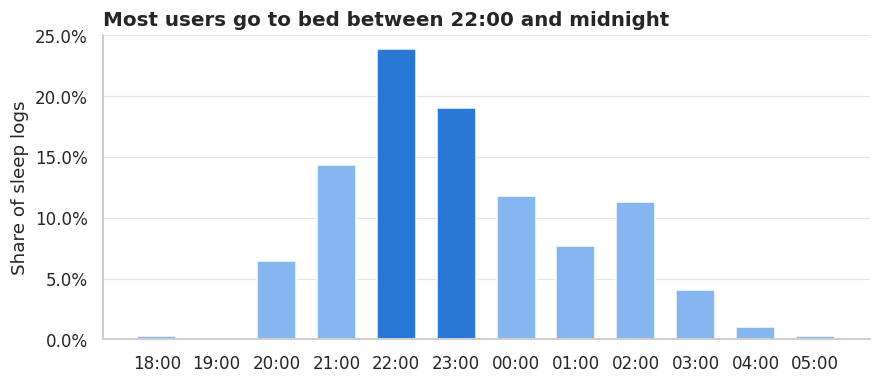

In [11]:
main = sess[sess.minutes_logged >= 180].copy()
order = list(range(18, 24)) + list(range(0, 6))
bt = main.bedtime_hour.value_counts().reindex(order, fill_value=0)

fig, ax = plt.subplots(figsize=(9, 3.6))
bars = ax.bar([f"{h:02d}:00" for h in bt.index], bt.values / bt.sum() * 100,
              color=[BLUE if h in (22, 23) else "#86b6ef" for h in bt.index], width=0.65)
ax.yaxis.set_major_formatter(mtick.PercentFormatter()); ax.set_ylabel("Share of sleep logs")
ax.set_title("Most users go to bed between 22:00 and midnight"); ax.grid(axis="x", visible=False)
save(fig, "08_bedtime"); plt.show()

## 7. Heart rate patterns (14 users)

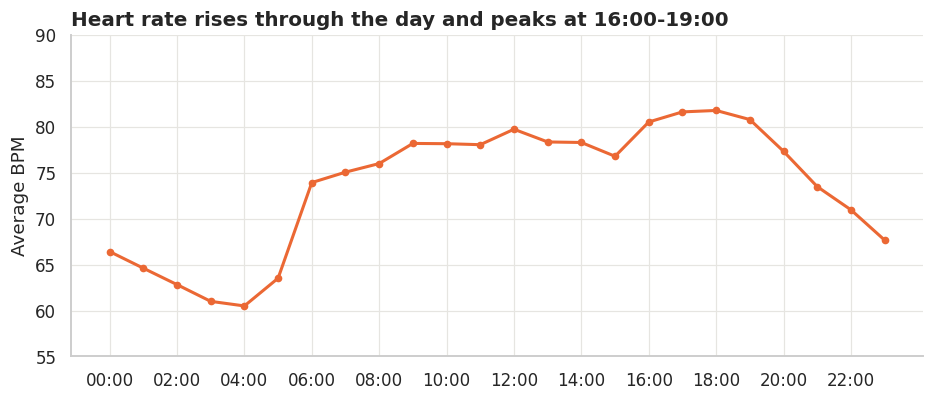

In [12]:
hr = hr_hour.groupby("hour_of_day").avg_bpm.mean()
fig, ax = plt.subplots(figsize=(10, 3.8))
ax.plot(hr.index, hr.values, color=ORANGE, lw=2, marker="o", ms=4)
ax.set_xticks(range(0, 24, 2)); ax.set_xticklabels([f"{h:02d}:00" for h in range(0, 24, 2)])
ax.set_ylabel("Average BPM"); ax.set_ylim(55, 90)
ax.set_title("Heart rate rises through the day and peaks at 16:00-19:00")
save(fig, "09_heart_rate_hourly"); plt.show()

**Insight:** Heart rate follows the activity curve. It is lowest at 03:00–05:00 (~60 BPM) and highest in the late afternoon and evening (~81 BPM), matching the after-work activity peak.

## 8. User segments and engagement

,users,avg_steps,days_worn,sed_h
Sedentary,7,3687.3,21.9,18.2
Low active,9,6549.9,24.2,18.1
Somewhat active,10,8790.6,28.4,13.1
Active,7,12680.1,29.7,16.3


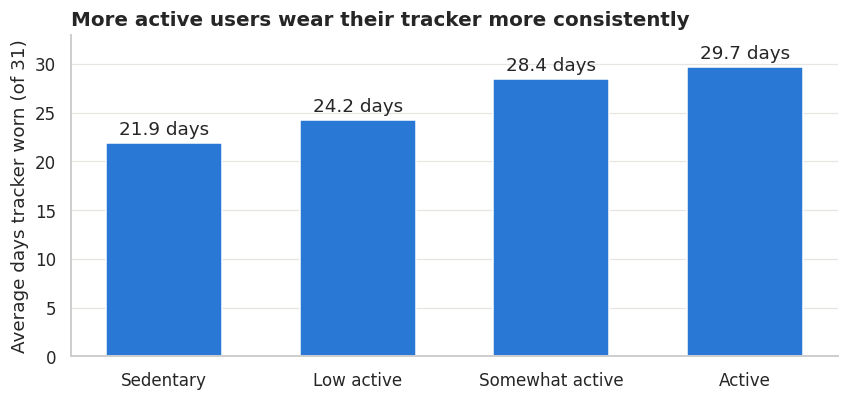

In [13]:
seg = users.groupby("activity_level").agg(users=("user_id", "count"), avg_steps=("avg_steps", "mean"),
                                          days_worn=("days_worn", "mean"), sed_h=("avg_sedentary_min", lambda s: s.mean() / 60))
seg.index = [i.split(". ")[1] for i in seg.index]
display(seg.round(1))

fig, ax = plt.subplots(figsize=(9, 3.8))
bars = ax.bar(seg.index, seg.days_worn, color=BLUE, width=0.6)
ax.bar_label(bars, fmt="%.1f days", padding=3); ax.set_ylim(0, 33)
ax.set_ylabel("Average days tracker worn (of 31)"); ax.grid(axis="x", visible=False)
ax.set_title("More active users wear their tracker more consistently")
save(fig, "10_segments_wear"); plt.show()

In [14]:
daily["study_week"] = ((pd.to_datetime(daily.activity_date) - pd.Timestamp("2016-04-12")).dt.days // 7) + 1
wk = daily.groupby("study_week").user_id.nunique()
print("Active users per study week (week 5 is only 3 days):"); print(wk)

wear = pd.cut(daily.logged_min, [0, 720, 1080, 1439, 1440], labels=["Under 12h", "12-18h", "18-24h", "All day"])
print("\nShare of days by wear time:"); print((wear.value_counts(normalize=True) * 100).round(1))

Active users per study week (week 5 is only 3 days):
study_week
1    33
2    31
3    32
4    29
5    22
Name: user_id, dtype: int64

Share of days by wear time:
logged_min
All day      46.9
12-18h       40.1
18-24h       10.4
Under 12h     2.5
Name: proportion, dtype: float64


**Insight:** 26 of 33 users wore the tracker on 21+ days, but about **half of all days are not full 24-hour wear**, and active users dropped from 33 to 29 by week 4. Wear consistency is itself something the product can improve.

## 9. Correlations

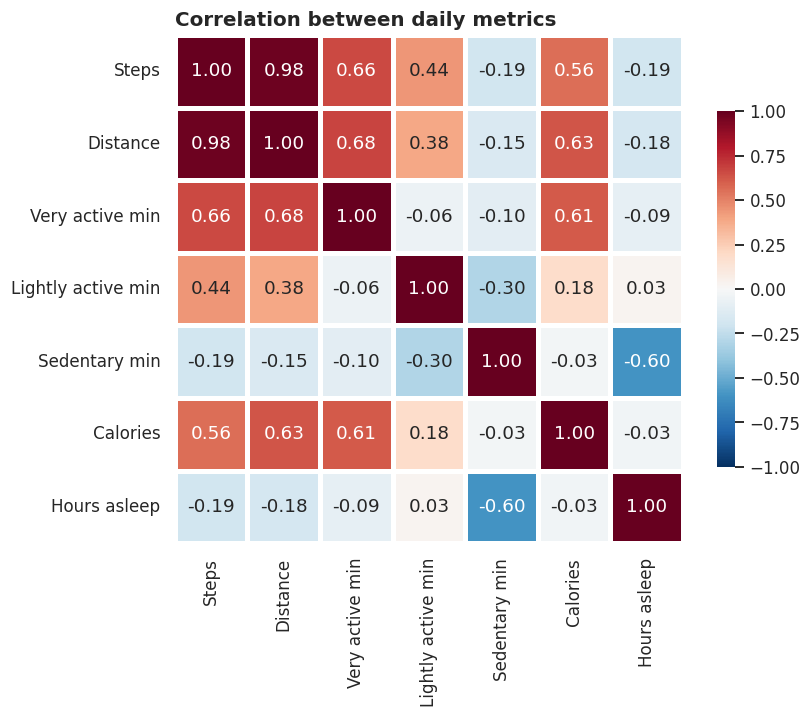

In [15]:
cols = {"total_steps": "Steps", "total_distance": "Distance", "very_active_min": "Very active min",
        "lightly_active_min": "Lightly active min", "sedentary_min": "Sedentary min",
        "calories": "Calories", "hours_asleep": "Hours asleep"}
corr = daily[list(cols)].rename(columns=cols).corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, center=0,
            linewidths=2, linecolor="white", square=True, cbar_kws={"shrink": 0.7}, ax=ax)
ax.set_title("Correlation between daily metrics")
save(fig, "11_correlation"); plt.show()

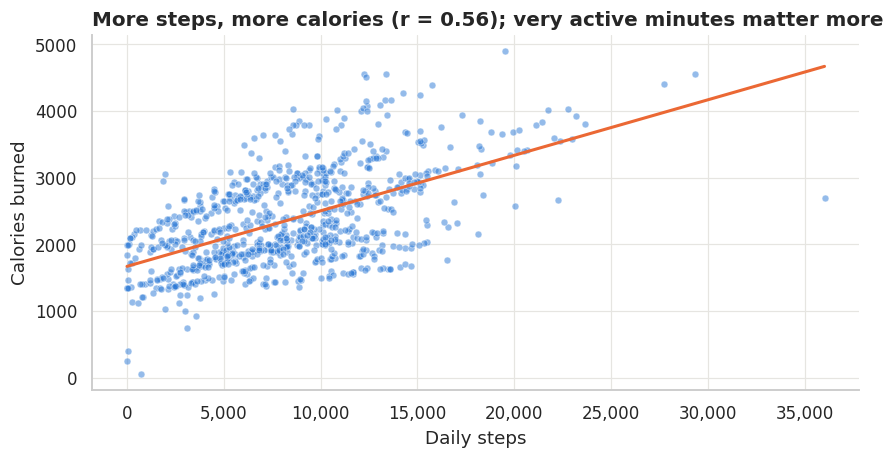

In [16]:
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.scatter(daily.total_steps, daily.calories, s=20, color=BLUE, alpha=0.5, edgecolor="white", linewidth=0.5)
m, b = np.polyfit(daily.total_steps, daily.calories, 1)
xs = np.linspace(0, daily.total_steps.max(), 50); ax.plot(xs, m * xs + b, color=ORANGE, lw=2)
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
ax.set_xlabel("Daily steps"); ax.set_ylabel("Calories burned")
ax.set_title(f"More steps, more calories (r = {daily[['total_steps','calories']].corr().iloc[0,1]:.2f}); very active minutes matter more")
save(fig, "12_steps_vs_calories"); plt.show()

**Insight:** Steps and calories are moderately correlated (r ≈ 0.56), but **very active minutes** correlate more strongly with calories than steps do. Intensity matters, not just step count.

## 10. Key findings

1. **Sedentary lifestyle:** 79 % of tracked time is sedentary; average ≈ 16 h/day. Only 35 % of days reach 10,000 steps.
2. **Light activity dominates:** users average ~210 lightly active minutes but only ~38 fairly/very active minutes per day.
3. **Timing:** weekday activity peaks at 17:00–19:00; weekends peak at midday. Sunday is the least active day.
4. **Sleep gap:** average sleep ≈ 7 h, but only 46 % of nights reach 7–9 h. More sedentary days are linked to less sleep.
5. **Feature adoption drops with friction:** 100 % activity → 73 % sleep → 42 % heart rate → 24 % weight (manual).
6. **Wear consistency:** about half of days are not 24-hour wear, and engagement fades towards the end of the month.

**Limitations:** 33 users, 31 days, data from 2016, no age/sex data (Bellabeat targets women), and the distance unit is unknown. Findings are directional and should be validated with Bellabeat's own app data.

In [17]:
conn.close()